In [4]:
!sudo apt install swig

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
swig is already the newest version (4.0.2-1ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 18 not upgraded.


In [5]:
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /tmp/pip-req-build-_9cwyf68
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /tmp/pip-req-build-_9cwyf68
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit 3c915e7f05f0b331d2e842aca5de0e36be3c1bb3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /tmp/pip-install-tegfwfpj/elegantrl_236ef02b62d94f90ba2ec66d1bd212f5
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /tmp/pip-install-tegfwfpj/elegantrl_236ef02b62d94f90ba2ec66d1bd212f5
  Resolved https://github.com/AI4Finance-Foundation/ElegantRL.git to commit 2fa34dd9236498beada8d8443d927970a9de1f7f
  Preparing metadata (setup.py) ... done


In [6]:
!pip install quantstats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.3 MB/s eta 0:00:00


In [7]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('matplotlib.font_manager').disabled = True

In [9]:
!pip install torch

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [11]:
!pip install torch_geometric

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.4 MB/s eta 0:00:00


In [12]:
import torch

import numpy as np

from sklearn.preprocessing import MaxAbsScaler

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import GroupByScaler
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv
from finrl.agents.portfolio_optimization.models import DRLAgent
from finrl.agents.portfolio_optimization.architectures import EIIE

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [13]:
TOP_BRL = [
    "VALE3.SA", "PETR4.SA", "ITUB4.SA", "BBDC4.SA",
    "BBAS3.SA", "RENT3.SA", "LREN3.SA", "PRIO3.SA",
    "WEGE3.SA", "ABEV3.SA"
]
print(len(TOP_BRL))

portfolio_raw_df = YahooDownloader(start_date = '2014-01-01',
                                end_date = '2024-12-31',
                                ticker_list = TOP_BRL).fetch_data()
portfolio_raw_df

10


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (27350, 8)


Price,date,close,high,low,open,volume,tic,day
0,2014-01-02,11.198844,17.498390,17.178419,17.298409,8036139,ABEV3.SA,3
1,2014-01-02,5.937234,12.240000,11.975000,12.225000,8155800,BBAS3.SA,3
2,2014-01-02,6.483239,11.465876,11.273798,11.383557,17581311,BBDC4.SA,3
3,2014-01-02,10.103780,15.897821,15.622339,15.797645,25333788,ITUB4.SA,3
4,2014-01-02,6.241997,8.373906,7.982248,8.298014,7260073,LREN3.SA,3
...,...,...,...,...,...,...,...,...
27345,2024-12-30,36.189999,36.369999,35.770000,35.779999,22355600,PETR4.SA,0
27346,2024-12-30,40.150002,40.650002,39.810001,40.150002,8758200,PRIO3.SA,0
27347,2024-12-30,32.200001,32.730000,31.900000,32.540001,7254000,RENT3.SA,0
27348,2024-12-30,54.549999,55.189999,54.549999,54.900002,11250900,VALE3.SA,0


In [14]:
portfolio_raw_df.groupby("tic").count()

Price,date,close,high,low,open,volume,day
tic,,,,,,,
ABEV3.SA,2735,2735,2735,2735,2735,2735,2735
BBAS3.SA,2735,2735,2735,2735,2735,2735,2735
BBDC4.SA,2735,2735,2735,2735,2735,2735,2735
ITUB4.SA,2735,2735,2735,2735,2735,2735,2735
LREN3.SA,2735,2735,2735,2735,2735,2735,2735
PETR4.SA,2735,2735,2735,2735,2735,2735,2735
PRIO3.SA,2735,2735,2735,2735,2735,2735,2735
RENT3.SA,2735,2735,2735,2735,2735,2735,2735
VALE3.SA,2735,2735,2735,2735,2735,2735,2735


In [15]:
portfolio_norm_df = GroupByScaler(by="tic", scaler=MaxAbsScaler).fit_transform(portfolio_raw_df)
portfolio_norm_df

Price,date,close,high,low,open,volume,tic,day
0,2014-01-02,0.589908,0.712475,0.714874,0.709242,0.027933,ABEV3.SA,0.75
1,2014-01-02,0.209678,0.408613,0.405520,0.410442,0.017946,BBAS3.SA,0.75
2,2014-01-02,0.298429,0.382100,0.384557,0.382614,0.035219,BBDC4.SA,0.75
3,2014-01-02,0.274918,0.399543,0.406832,0.408525,0.157676,ITUB4.SA,0.75
4,2014-01-02,0.144625,0.167705,0.162070,0.166349,0.037217,LREN3.SA,0.75
...,...,...,...,...,...,...,...,...
27345,2024-12-30,0.961693,0.846996,0.840461,0.836568,0.031985,PETR4.SA,0.00
27346,2024-12-30,0.789422,0.779781,0.789255,0.777950,0.054084,PRIO3.SA,0.00
27347,2024-12-30,0.472154,0.442894,0.440810,0.442219,0.080237,RENT3.SA,0.00
27348,2024-12-30,0.646618,0.458198,0.473319,0.458264,0.061301,VALE3.SA,0.00


In [63]:
df_portfolio = portfolio_norm_df[["date", "tic", "close", "high", "low"]]

df_portfolio_train = df_portfolio[(df_portfolio["date"] >= "2014-01-01") & (df_portfolio["date"] < "2021-12-31")]
df_portfolio_2022 = df_portfolio[(df_portfolio["date"] >= "2022-01-01") & (df_portfolio["date"] < "2022-12-31")]
df_portfolio_2023 = df_portfolio[(df_portfolio["date"] >= "2023-01-01") & (df_portfolio["date"] < "2023-12-31")]
df_portfolio_2024 = df_portfolio[(df_portfolio["date"] >= "2024-01-01") & (df_portfolio["date"] < "2024-12-31")]

environment = PortfolioOptimizationEnv(
  df_portfolio_train,
  initial_amount=100000,
  comission_fee_pct=0.0025,
  time_window=50,
  features=["close", "high", "low"],
  normalize_df=None
)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [56]:
model_kwargs = {
    "lr": 0.01,
    "policy": EIIE,
}
policy_kwargs = {
    "k_size": 3,
    "time_window": 50,
}

model = DRLAgent(environment).get_model("pg", device, model_kwargs, policy_kwargs)

In [57]:
DRLAgent.train_model(model, episodes=40)

  0%|          | 0/40 [00:00<?, ?it/s]

Initial portfolio value:100000
Final portfolio value: 479092.84375
Final accumulative portfolio value: 4.7909284375
Maximum DrawDown: -0.44842331567738913
Sharpe ratio: 0.8824153798992144


  2%|▎         | 1/40 [00:27<17:46, 27.34s/it]

Initial portfolio value:100000
Final portfolio value: 491755.25
Final accumulative portfolio value: 4.9175525
Maximum DrawDown: -0.4474930784348484
Sharpe ratio: 0.896259890389738


  5%|▌         | 2/40 [00:54<17:21, 27.41s/it]

...

 95%|█████████▌| 38/40 [17:38<00:55, 27.91s/it]

Initial portfolio value:100000
Final portfolio value: 550771.4375
Final accumulative portfolio value: 5.507714375
Maximum DrawDown: -0.47607157665628264
Sharpe ratio: 0.8990729934143988


 98%|█████████▊| 39/40 [18:06<00:27, 27.91s/it]

Initial portfolio value:100000
Final portfolio value: 551125.75
Final accumulative portfolio value: 5.5112575
Maximum DrawDown: -0.4762440872430398
Sharpe ratio: 0.8990813501683594


100%|██████████| 40/40 [18:34<00:00, 27.85s/it]


In [58]:
torch.save(model.train_policy.state_dict(), "policy_EIIE.pt")

In [64]:
environment_2022 = PortfolioOptimizationEnv(
    df_portfolio_2022,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=["close", "high", "low"],
    normalize_df=None
)

environment_2023 = PortfolioOptimizationEnv(
    df_portfolio_2023,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=["close", "high", "low"],
    normalize_df=None
)

environment_2024 = PortfolioOptimizationEnv(
    df_portfolio_2024,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=["close", "high", "low"],
    normalize_df=None
)

In [65]:
EIIE_results = {
    "training": environment._asset_memory["final"],
    "2022": {},
    "2023": {},
    "2024": {}
}

policy = EIIE(time_window=50, device=device)
policy.load_state_dict(torch.load("policy_EIIE.pt"))

DRLAgent.DRL_validation(model, environment_2022, policy=policy)
EIIE_results["2022"]["value"] = environment_2022._asset_memory["final"]

DRLAgent.DRL_validation(model, environment_2023, policy=policy)
EIIE_results["2023"]["value"] = environment_2023._asset_memory["final"]

DRLAgent.DRL_validation(model, environment_2024, policy=policy)
EIIE_results["2024"]["value"] = environment_2024._asset_memory["final"]

Initial portfolio value:100000
Final portfolio value: 113446.09375
Final accumulative portfolio value: 1.1344609375
Maximum DrawDown: -0.16435416226644972
Sharpe ratio: 0.8181983063391838
Initial portfolio value:100000
Final portfolio value: 127662.0703125
Final accumulative portfolio value: 1.276620703125
Maximum DrawDown: -0.10569681247416318
Sharpe ratio: 1.8995882435847757
Initial portfolio value:100000
Final portfolio value: 94019.7109375
Final accumulative portfolio value: 0.940197109375
Maximum DrawDown: -0.12826134449666637
Sharpe ratio: -0.4684763199240281


In [68]:
UBAH_results = {
    "train": {},
    "2022": {},
    "2023": {},
    "2024": {}
}

PORTFOLIO_SIZE = len(TOP_BRL)

# train period
terminated = False
environment.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment.step(action)
UBAH_results["train"]["value"] = environment._asset_memory["final"]

# 2020
terminated = False
environment_2022.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2022.step(action)
UBAH_results["2022"]["value"] = environment_2022._asset_memory["final"]

# 2021
terminated = False
environment_2023.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2023.step(action)
UBAH_results["2023"]["value"] = environment_2023._asset_memory["final"]

# 2022
terminated = False
environment_2024.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2024.step(action)
UBAH_results["2024"]["value"] = environment_2024._asset_memory["final"]

Initial portfolio value:100000
Final portfolio value: 562757.0
Final accumulative portfolio value: 5.62757
Maximum DrawDown: -0.48198844774450444
Sharpe ratio: 0.899126613098332
Initial portfolio value:100000
Final portfolio value: 113634.3828125
Final accumulative portfolio value: 1.136343828125
Maximum DrawDown: -0.16660088433626563
Sharpe ratio: 0.8187493828473911
Initial portfolio value:100000
Final portfolio value: 128098.5234375
Final accumulative portfolio value: 1.280985234375
Maximum DrawDown: -0.10718298500703616
Sharpe ratio: 1.8995025571058257
Initial portfolio value:100000
Final portfolio value: 93920.078125
Final accumulative portfolio value: 0.93920078125
Maximum DrawDown: -0.13016231805830458
Sharpe ratio: -0.46830183013890087


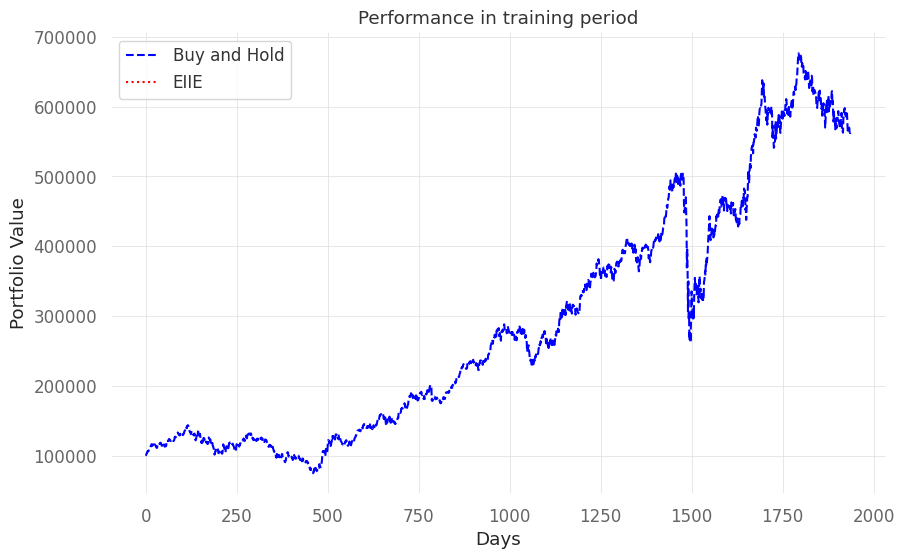

In [77]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

ubah_values = np.array(UBAH_results["train"]["value"])
eiie_values = np.array(EIIE_results["training"])

plt.plot(UBAH_results["train"]["value"], label="Buy and Hold", color='blue', linestyle="dashed")
plt.plot(EIIE_results["training"], label="EIIE", color='red', linestyle="dotted")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in training period")
plt.legend()
plt.show()

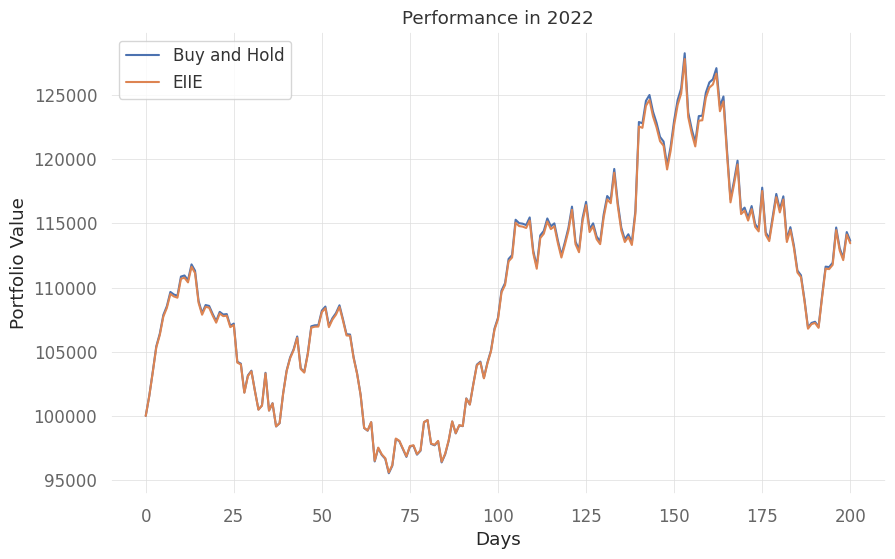

In [71]:
plt.plot(UBAH_results["2022"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2022"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2022")
plt.legend()

plt.show()

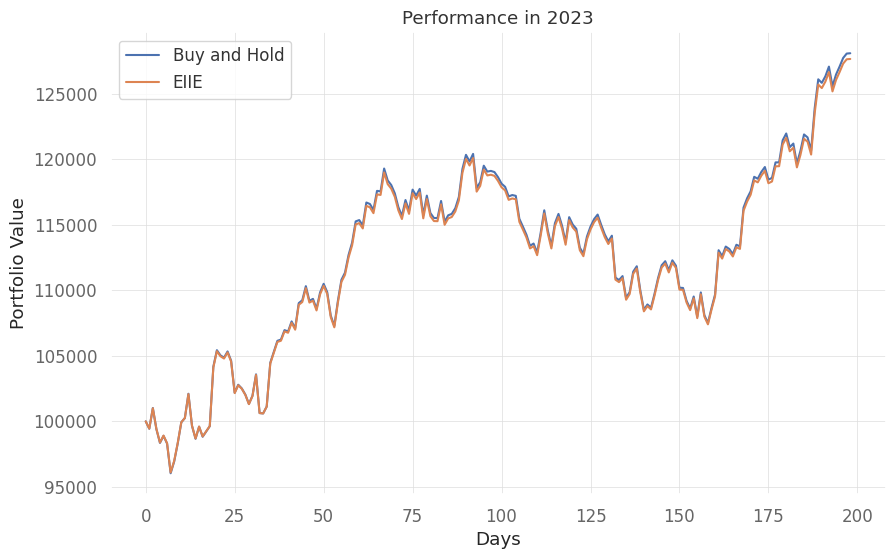

In [78]:
plt.plot(UBAH_results["2023"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2023"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2023")
plt.legend()

plt.show()

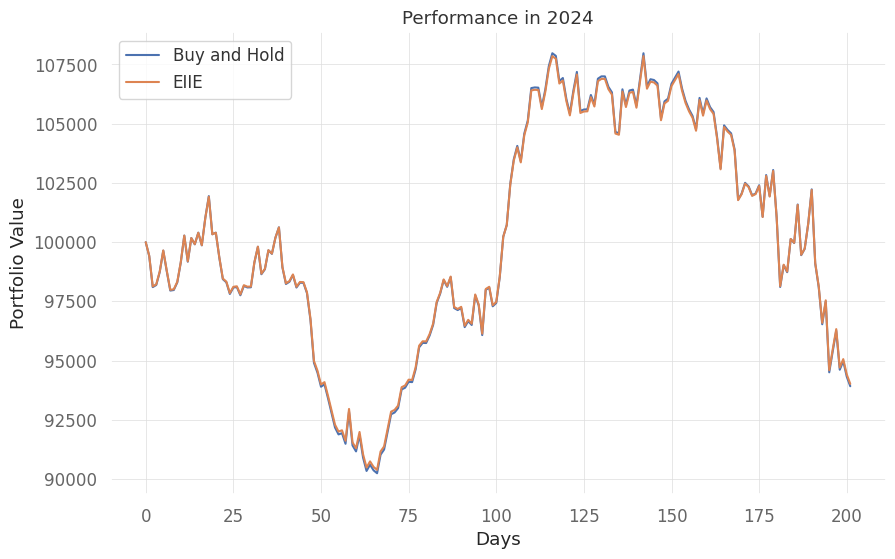

In [79]:
plt.plot(UBAH_results["2024"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2024"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2024")
plt.legend()

plt.show()